In [7]:
import re
import pandas as pd
import torch
import numpy as np
from tqdm import tqdm
from torch.nn.functional import pad
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import matplotlib.colors as mcolors

In [8]:
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
from transformers import LlamaForCausalLM, LlamaTokenizerFast

import argparse
import pickle
import os
import json
import pandas as pd

model_id = "gpt2"
device = "cuda:1"
perplexity_func = "p1"

if "gpt2" in model_id:
    model = GPT2LMHeadModel.from_pretrained(model_id).to(device)
    tokenizer = GPT2TokenizerFast.from_pretrained(model_id)
    start_of_sentence=" "
print(f"Loaded model: {model_id}")

Loaded model: gpt2


In [9]:
model_id = "gpt2"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model : GPT2LMHeadModel = GPT2LMHeadModel.from_pretrained(model_id).to(device)
tokenizer : GPT2TokenizerFast = GPT2TokenizerFast.from_pretrained(model_id)

In [10]:

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm
from torch.nn.functional import pad

def compute_graph_perplexity(tokens_list, p1, p2, matches, names, answers=None):
    dialog = [tokenizer.decode(token, skip_special_tokens=True) for token in tokens_list]
    
    # rows = int(np.ceil(np.sqrt(len(dialog))))
    rows = int(np.ceil(len(dialog)/6.0))
    # Create an 8x8 grid of subplots
    fig, axes = plt.subplots(rows, 6, figsize=(30, 15))
    num_plots = len(dialog)
    # Set smaller font size
    plt.rcParams.update({'font.size': 8})
    
    assert num_plots == len(matches)
    encodings = torch.cat(tokens_list)
    tokens_ids_per_sentence = np.cumsum([t.size(0) for t in tokens_list])
    assert tokens_ids_per_sentence[-1] == len(p1)
    
    # Compute global y-limits across all p1 and p2 values
    all_values = []
    prev_idx_pp = 0
    for idx in range(len(dialog)):
        idx_pp = tokens_ids_per_sentence[idx]
        p1_per_sent = p1[prev_idx_pp:idx_pp]
        p2_per_sent = p2[prev_idx_pp:idx_pp]
        all_values.extend(p1_per_sent)
        all_values.extend(p2_per_sent)
        prev_idx_pp = idx_pp

    # Filter out NaNs and compute global limits
    all_values = np.array(all_values)
    global_min = np.nanmin(all_values)
    global_max = np.nanmax(all_values)

    prev_idx_pp = 0
    for idx, ax in enumerate(axes.flatten()):
        if idx < num_plots:
            idx_pp = tokens_ids_per_sentence[idx]
            patt = matches[idx]
            sub_tokens = encodings[prev_idx_pp:idx_pp]
            decoded = [tokenizer.decode([token], skip_special_tokens=True) for token in sub_tokens]
            p1_per_sent = p1[prev_idx_pp:idx_pp]
            p2_per_sent = p2[prev_idx_pp:idx_pp]
            p1_name = names['p1']
            ax.plot(np.asarray(p1_per_sent), label=f'{patt} {p1_name}')
            #ax.plot(np.asarray(p2_per_sent), label=f'{patt} p2', color='r')
            #mean_value=np.nanmean(np.asarray(perpl_per_sent))
            # ax.axhline(p1_per_sent[0], color='g', label=f'{patt} p3')  # Fixed the color argument
            p2_name = names['p2']
            ax.plot(np.asarray(p2_per_sent), label=f'{patt} {p2_name}', color='g')
            ax.set_xticks(np.arange(len(decoded)))
            ax.set_xticklabels(decoded, rotation=90)
            if answers is not None:
                ax.set_title(f'{answers[idx]}')
            ax.legend()
            prev_idx_pp=idx_pp

            ax.set_ylim(global_min, global_max)

    # Hide any remaining empty subplots
    for ax in axes.flatten()[num_plots:]:
        ax.axis('off')
        
    plt.subplots_adjust(hspace=0.5, top=0.95)  
    plt.suptitle("Per-Word Perplexity across the Dataset", fontsize=30)
    plt.legend()
    plt.show()


def display_colored_sentences(tokens_list, p1, bound = None):
    encodings = torch.cat(tokens_list)
    decoded_tokens = [tokenizer.decode([token], skip_special_tokens=False) for token in encodings]

    tokens_ids_per_sentence = np.cumsum([t.size(0) for t in tokens_list])
    assert tokens_ids_per_sentence[-1] == len(p1)

    global_min = np.nanmin(p1)
    global_max = np.nanmax(p1)
    if bound != None:
        global_min, global_max = bound

    # Create a white-to-red colormap
    cmap = plt.cm.Reds
    cmap = cmap(np.linspace(0, 1, 256))
    # cmap[:50, :] = 1  # make the first 50 entries white (RGBA=1,1,1,1)
    white_to_red = mcolors.ListedColormap(cmap)

    html_output = ""
    prev_idx_pp = 0

    for idx in range(len(tokens_list)):
        idx_pp = tokens_ids_per_sentence[idx]
        sentence_tokens = decoded_tokens[prev_idx_pp:idx_pp]
        sentence_p1 = p1[prev_idx_pp:idx_pp]

        colored_sentence = ""
        for token, score in zip(sentence_tokens, sentence_p1):
            token = token.strip()
            token = token.replace("<", "&lt;").replace(">", "&gt;")

            if global_max == global_min:
                norm_score = 0.0
            else:
                norm_score = (score - global_min) / (global_max - global_min)
            r, g, b, _ = white_to_red(norm_score)
            color = mcolors.to_hex((r, g, b))
            colored_sentence += f'<span style="color:{color}">{str(token)}</span> '
        html_output += f"<span style='line-height:1.8em; font-size:130%; font-weight: bolder;'>{colored_sentence}</span><br>"
        prev_idx_pp = idx_pp

    # Display the HTML sentences
    display(HTML(html_output))

    # Create the color bar
    fig, ax = plt.subplots(figsize=(6, 1))
    norm = plt.Normalize(vmin=global_min, vmax=global_max)
    fig.subplots_adjust(bottom=0.5)

    cb1 = plt.colorbar(
        plt.cm.ScalarMappable(norm=norm, cmap=white_to_red),
        cax=ax, orientation='horizontal'
    )
    cb1.set_label('Perplexity')
    plt.show()

import re

def preprocess(text, pattern=r'<(SPK[1-9]|MOD)>'):
    matches = re.findall(pattern, text)
    dialog = text.replace('\n', '')
    dialog = re.sub(pattern, lambda m: '\n' + m.group(0), dialog)
    dialog_lines = [
        line.strip()
        for line in dialog.split('\n')
        if line.strip()
    ]

    return dialog_lines, matches


In [11]:
def get_token_nll(input_ids, model, device, trg_len=-1, tokenizer=None, debug=False):
    input_ids = input_ids.to(device)
    target_ids = input_ids.clone()
    target_ids[:, :trg_len] = -100  # mask all tokens except the last one

    masked = [tokenizer.decode(token, skip_special_tokens=True) for token in input_ids[:, :trg_len]]
    computed = [tokenizer.decode(token, skip_special_tokens=True) for token in target_ids[:, trg_len:]]
    
    if debug:
        print(f"{masked} | {computed}")

    with torch.no_grad():
        output = model(input_ids, labels=target_ids)
        loss = output.loss.item()

    return loss


def get_token_spans(dialog, tokenizer):
    """Returns list of token spans for each turn."""
    spans = []
    total_tokens = []
    for turn in dialog:
        tokens = tokenizer(turn, return_tensors="pt").input_ids[0]
        spans.append((len(total_tokens), len(total_tokens) + len(tokens)))
        total_tokens.extend(tokens.tolist())
    return spans, torch.tensor(total_tokens)


In [12]:
def compute_p1(encodings, token_list, tokenizer, model, device, start_of_sentence=" ", pattern = r'<(?:SPK[0-9]|MOD)>', debug=False):

    max_length = 500
    stride = 1
    
    pad_token_id = 0
    seq_len = encodings.input_ids.size(1)
    padding_len = max_length -1 
    padded_input_ids = pad(torch.tensor([], dtype=torch.long), (0, padding_len), value=pad_token_id).unsqueeze(dim=0)
    padded_input_ids = torch.cat([padded_input_ids, encodings.input_ids], dim=1)
    seq_len = padded_input_ids.size(1)
    
    nlls = []
    prev_end_loc = padding_len
    for begin_loc in tqdm(range(0, seq_len, stride)):
        end_loc = min(begin_loc + max_length, seq_len)
        trg_len = end_loc - prev_end_loc  # may be different from max_length on the last loop 
        begin_loc = max(padding_len, begin_loc)
        input_ids = padded_input_ids[:, begin_loc:end_loc].to(device)
    
        loss = get_token_nll(
            input_ids=input_ids,
            model=model,
            device=device,
            trg_len=-trg_len,
            tokenizer=tokenizer,
            debug=debug,
        )
        
        nlls.append(loss)

        prev_end_loc = end_loc
        if end_loc == seq_len:
            break
    return nlls

In [13]:
import numpy as np
from torch.nn.functional import pad
    
def compute_p2(encodings, token_list, tokenizer, model, device, start_of_sentence=" ", pattern = r'<(?:SPK[0-9]|MOD)>', debug=False):
    max_length = 500
    stride = 1

    pad_token_id = 0
    assert len([t for token in token_list for t in token]) == encodings.input_ids.size(1)

    turn_len = [len(token) for token in token_list]
    turn_mask = offset_mask = np.concatenate([
        np.arange(length) for length in turn_len
    ])
    assert len(turn_mask) == sum(turn_len)

    seq_len = encodings.input_ids.size(1)
    padding_len = max_length -1 
    padded_input_ids = pad(torch.tensor([], dtype=torch.long), (0, padding_len), value=pad_token_id).unsqueeze(dim=0)
    padded_input_ids = torch.cat([padded_input_ids, encodings.input_ids], dim=1)
    seq_len = padded_input_ids.size(1)

    nlls = []
    prev_end_loc = padding_len
    for begin_loc in tqdm(range(0, seq_len, stride)):
        end_loc = min(begin_loc + max_length, seq_len)
        offset = turn_mask[begin_loc]
        trg_len = end_loc - prev_end_loc + offset  # may be different from max_length on the last loop 
        begin_loc = max(padding_len, begin_loc)
        input_ids = padded_input_ids[:, begin_loc:end_loc].to(device)

        loss = get_token_nll(
            input_ids=input_ids,
            model=model,
            device=device,
            trg_len=-trg_len,
            tokenizer=tokenizer,
            debug=debug
        )

        nlls.append(loss)

        prev_end_loc = end_loc
        if end_loc == seq_len:
            break

    return nlls

In [14]:
import numpy as np
from torch.nn.functional import pad
from tqdm import tqdm
    
def compute_p3(encodings, token_list, tokenizer, model, device, start_of_sentence=" ", pattern = r'<(?:SPK[0-9]|MOD)>', debug=False):
    
    max_length = 500
    stride = 1
    pad_token_id = 0
    assert len([t for token in token_list for t in token]) == encodings.input_ids.size(1)

    turn_len = [len(token) for token in token_list]
    turn_mask = np.repeat(range(len(turn_len)), turn_len)
    max_val = turn_mask.max()
    turn_mask = torch.tensor([(turn_mask + 1) % (max_val + 1)])

    assert len(turn_mask[0]) == sum(turn_len)

    seq_len = encodings.input_ids.size(1)
    padding_len = max_length -1 
    padded_input_ids = pad(torch.tensor([], dtype=torch.long), (0, padding_len), value=pad_token_id).unsqueeze(dim=0)
    turn_mask = torch.cat([padded_input_ids, turn_mask], dim=1)
    padded_input_ids = torch.cat([padded_input_ids, encodings.input_ids], dim=1)
    seq_len = padded_input_ids.size(1)

    nlls = []
    prev_end_loc = padding_len
    for begin_loc in tqdm(range(0, seq_len, stride)):
        end_loc = min(begin_loc + max_length, seq_len)
        trg_len = end_loc - prev_end_loc
        begin_loc = max(padding_len, begin_loc)

        sentence = tokenizer.decode(token_list[turn_mask[0, prev_end_loc]],skip_special_tokens=True)
        match = re.findall(pattern, sentence)
        len_match = tokenizer(match, return_tensors="pt").input_ids.size(1)
        offset = token_list[turn_mask[0, prev_end_loc]][:len_match].unsqueeze(0)
        input_ids_aug = torch.cat([padded_input_ids[:, begin_loc:end_loc], offset], dim=1).to(device)
        loss = get_token_nll(
            input_ids=input_ids_aug,
            model=model,
            device=device,
            trg_len=-len_match,
            tokenizer=tokenizer,
            debug=debug
        )
        nlls.append(loss)

        prev_end_loc = end_loc
        if end_loc == seq_len:
            break


    return nlls

### Experiments

In [15]:
el = " B So, thanks for coming today. We're going to play a quick quiz. I’m going to ask you three questions, and I would like you to guess the three most popular answers to these questions, which were posed to a group of one hundred people. B Ok, sounds good. B Alright, I’m going to ask the first question: What do people normally use to transport patients in a hospital? Think about things like an ambulance, a wheelchair, or a patient's bed. What would you say, E ? E Mhmm… um, ambulance? B Correct, and can you guess the next two most popular answers? E Hmm... wheelchair? B Yes, good! And the third one? E Maybe... a stretcher? B Exactly! Well done. Now, let's move on to the second question. This one is a little different: What do you think is the most popular type of vacation destination? Some of the answers we got were beach resorts, mountain retreats, and city stays. Can you guess the top three? E Uh… beach resorts? B Yes, that’s number one! What about number two? E Mountain retreat? B Exactly. And number three? E Uh… city stays? B Perfect! Now we have the last one: What is the most common drink people enjoy at breakfast? Can you guess? E Coffee? B Right! What else? E Maybe... juice? B Correct! And the third one? E Milk? B Yes, that’s exactly right! Well done! You got all the answers!"

dialog_first_dominant = """
<SPK1> Please sit down. We need to talk about your work.
<SPK2> Yes.
<SPK1> Your report was full of mistakes. Did you even check it before sending?
<SPK2> No, sorry.
<SPK1> It looked rushed and unprofessional. That is not acceptable.
<SPK2> I am sorry. I was confused about the instructions.
<SPK1> Then you should have asked. I do not want excuses, I want solutions.
<SPK2> I understand. I will fix it.
<SPK1> Not just fix it. Learn from it. This cannot happen again.
<SPK2> Sure, I understand.
<SPK1> I will send the corrections. I want the new version by tonight. No delays.
<SPK2> Alright.
<SPK1> Also, from now on, update me every morning. I want to know your progress. 
<SPK2> Okay. I will send a message each morning.
"""

dialog_second_dominant = """
<SPK1> I study English sometimes, but it is hard for me.
<SPK2> That is because you are not doing it every day. Are you practicing speaking often?
<SPK1> Not really. I just watch videos or read a little.
<SPK2> That is not enough. You need to speak, even if it feels strange. Talk to people or even to yourself.
<SPK1> I feel shy when I speak. I think I make too many mistakes.
<SPK2> Mistakes are normal. You cannot learn without making them. I make mistakes too, but I keep speaking.
<SPK1> Maybe I should try more. I want to speak better.
<SPK2> Then do it. Make a schedule. Ten minutes of speaking, twenty minutes of listening. Every single day.
<SPK1> That sounds like a lot. I am not sure I can do it.
<SPK2> You can. You just need to stop thinking and start doing. Use your time well. No excuses.
<SPK1> I guess I waste a lot of time on my phone.
<SPK2> Then use your phone for learning. Change your apps to English, listen to podcasts, use a dictionary app.
<SPK1> Those are good ideas. I never thought of that.
<SPK2> That is the problem. Most people want to improve but do not think smart. Be active. Control your learning.
<SPK1> I will try to change my habits.
<SPK2> Good. Start today, not tomorrow. Even ten minutes is better than nothing.
<SPK1> Alright. I will do something after this conversation.
<SPK2> That is the spirit. Keep going and do not stop. In a few months, you will see big changes.
<SPK1> Thank you for the advice. It is very helpful.
<SPK2> You are welcome. Now go and study. You have work to do.
"""

dialog_first_dominant_2 = """
<SPK1> You are late again. We said nine o clock, do you remember?
<SPK2> I am really sorry.
<SPK1> That is not the first time. You always have some excuse.
<SPK2> I did not want to be late.
<SPK1> But it still happened. You need to plan better. It is important to be on time, especially for group work.
<SPK1> When you are late, we all wait. We lose time. It is not fair.
<SPK2> I understand. 
<SPK1> Do not just try, you must do it. We have a lot to finish today.
<SPK2> What should I start with?
<SPK1> Begin with the list I gave you yesterday. Did you read it?
<SPK2> No, not yet.
<SPK1> That is not good enough. You had one job. We cannot work like this.
<SPK1> From now on, I need you to be more serious. This is not a game.
<SPK2> You are right.
"""

dialog_second_dominant_2 = """
<SPK1> I think we should meet tomorrow to finish the project.
<SPK2> No, we will meet today. We are already behind, and I want results.
<SPK1> But I have some other things planned for today.
<SPK2> Then cancel them. This is more important right now.
<SPK1> I understand, but I thought we agreed on taking it slow.
<SPK2> That was before I saw the deadline. We do not have time to be slow.
<SPK2> I already started my part. You need to catch up.
<SPK1> Alright. I will try to finish my tasks today.
<SPK2> Do not try. Just do it. I do not want excuses later.
<SPK1> Okay. I will do it.
<SPK2> Good. I will check everything tonight. Make sure it is ready.
<SPK1> Should I send it by email?
<SPK2> No, send it in the shared folder. I want everything in one place.
<SPK2> And next time, be more proactive. I cannot lead this alone.
<SPK1> Yes, I will be more careful.
"""

dialog_second_dominant_3 = """
<SPK1> Hi.
<SPK2> Hi. Listen to me carefully. I have already decided how things will go.
<SPK1> Okay.
<SPK2> From now on, you will report to me every morning. No exceptions.
"""


In [16]:
pattern = r'<(?:SPK[0-9]|MOD)>'
dialog = dialog_second_dominant_2.split("\n")[1:-1]
start_of_sentence=" "
matches = re.findall(pattern, "".join(dialog))
token_list = [tokenizer(token, return_tensors="pt", return_offsets_mapping=True).input_ids[0] for token in dialog]
encodings = tokenizer(f"{start_of_sentence}".join(dialog), return_tensors="pt")

In [17]:
ppl1_dialog_second_dominant = compute_p1(encodings, token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)

 34%|███████████████████████████████████████████████████████████▍                                                                                                                   | 257/757 [00:03<00:07, 66.73it/s]


In [18]:
ppl2_dialog_second_dominant = compute_p2(encodings, token_list, tokenizer, model, device, pattern=pattern, debug=False)

 34%|███████████████████████████████████████████████████████████▍                                                                                                                   | 257/757 [00:03<00:06, 78.41it/s]


In [19]:
ppl3_dialog_second_dominant = compute_p3(encodings, token_list, tokenizer, model, device, pattern = pattern, debug=False)

/tmp/ipykernel_1574880/71832609.py:15: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:245.)
  turn_mask = torch.tensor([(turn_mask + 1) % (max_val + 1)])
 34%|███████████████████████████████████████████████████████████▍                                                                                                                   | 257/757 [00:03<00:06, 74.42it/s]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


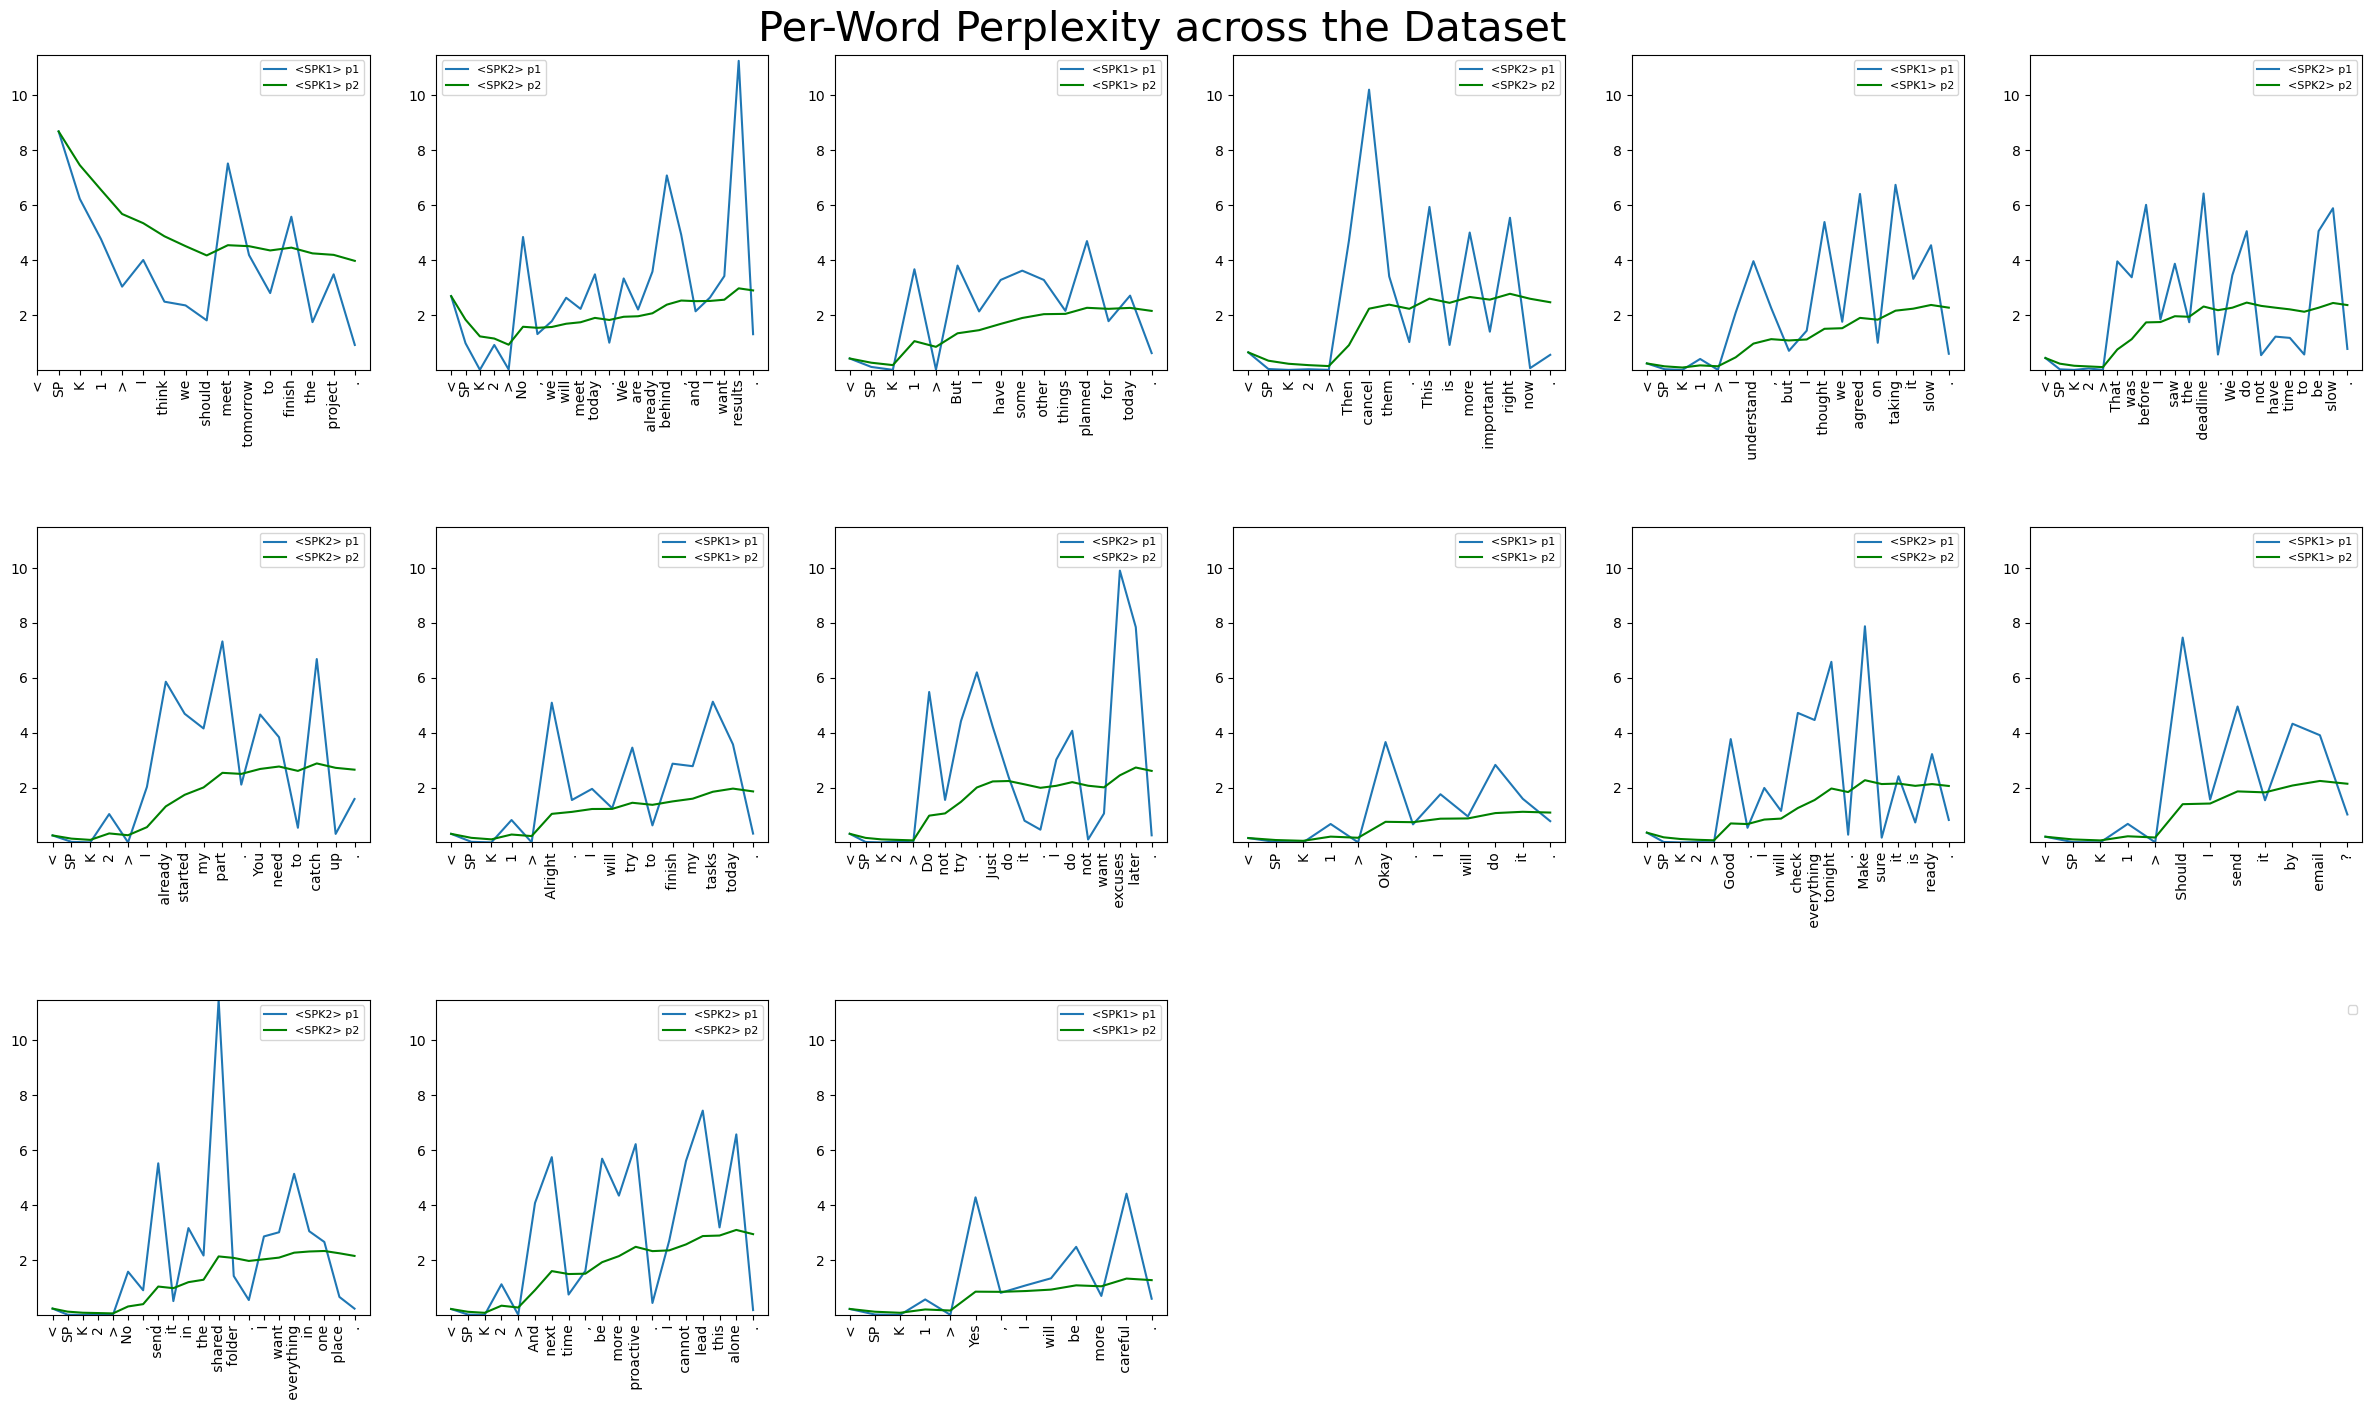

In [20]:
assert len(ppl1_dialog_second_dominant) == len(ppl2_dialog_second_dominant)
compute_graph_perplexity(token_list, ppl1_dialog_second_dominant, ppl2_dialog_second_dominant, matches, names={"p1":"p1", "p2":"p2"})

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


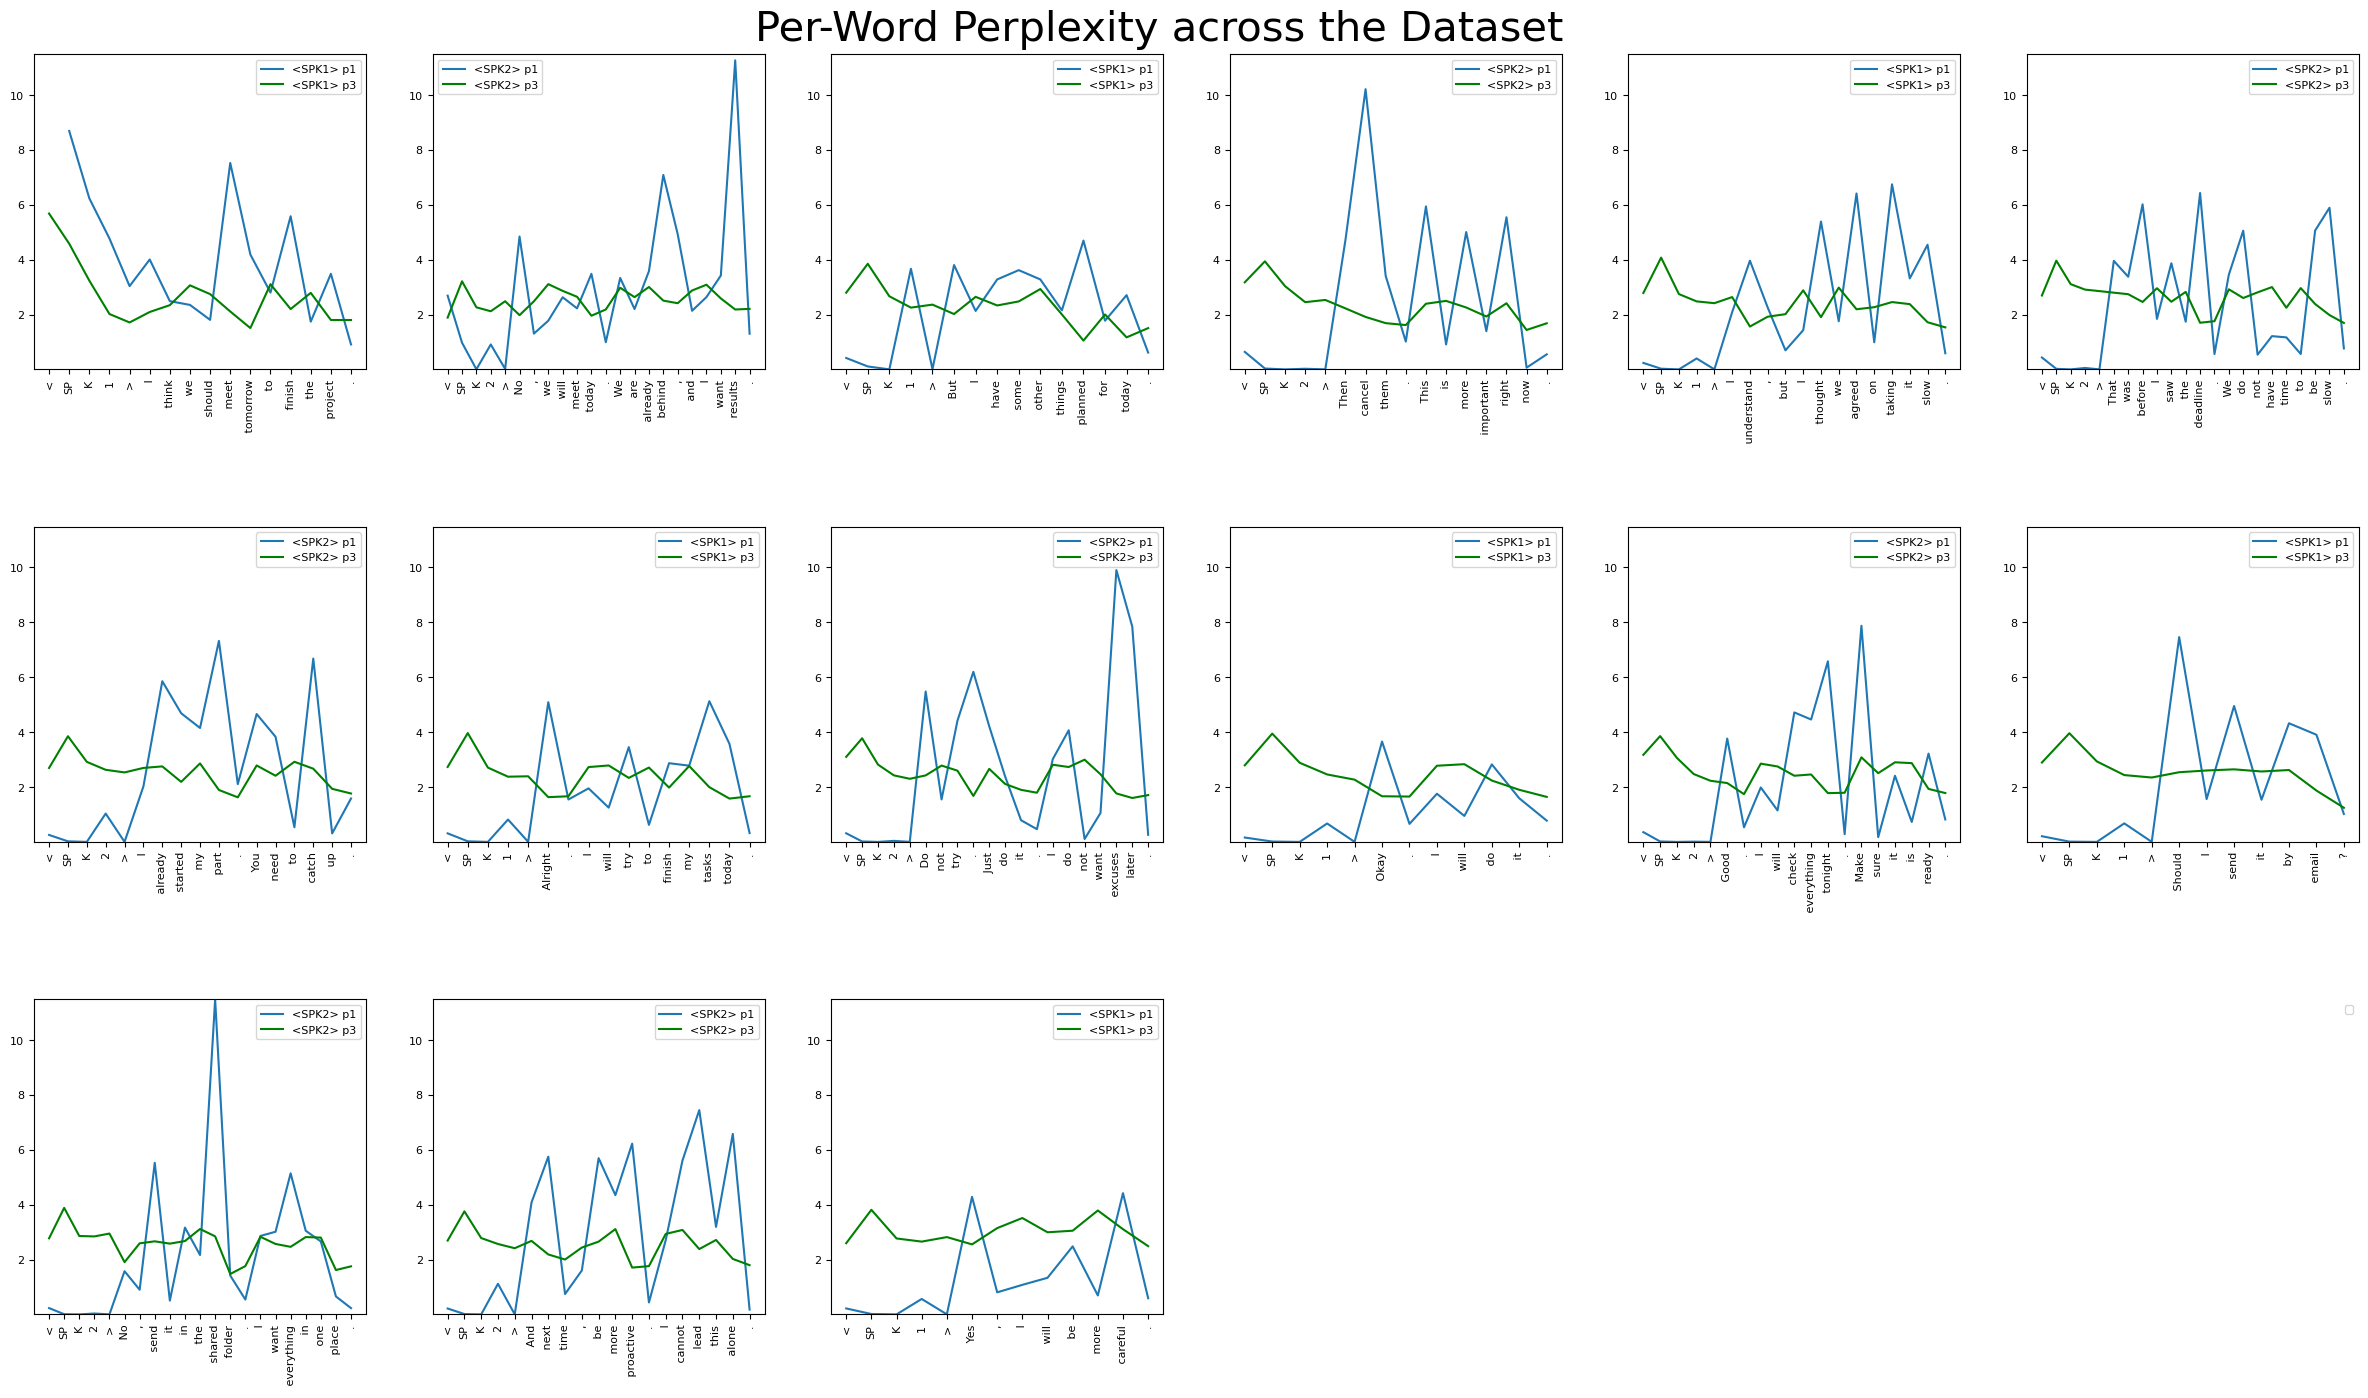

In [21]:
assert len(ppl1_dialog_second_dominant) == len(ppl3_dialog_second_dominant)
compute_graph_perplexity(token_list, ppl1_dialog_second_dominant, ppl3_dialog_second_dominant, matches, names={"p1":"p1", "p2":"p3"})

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


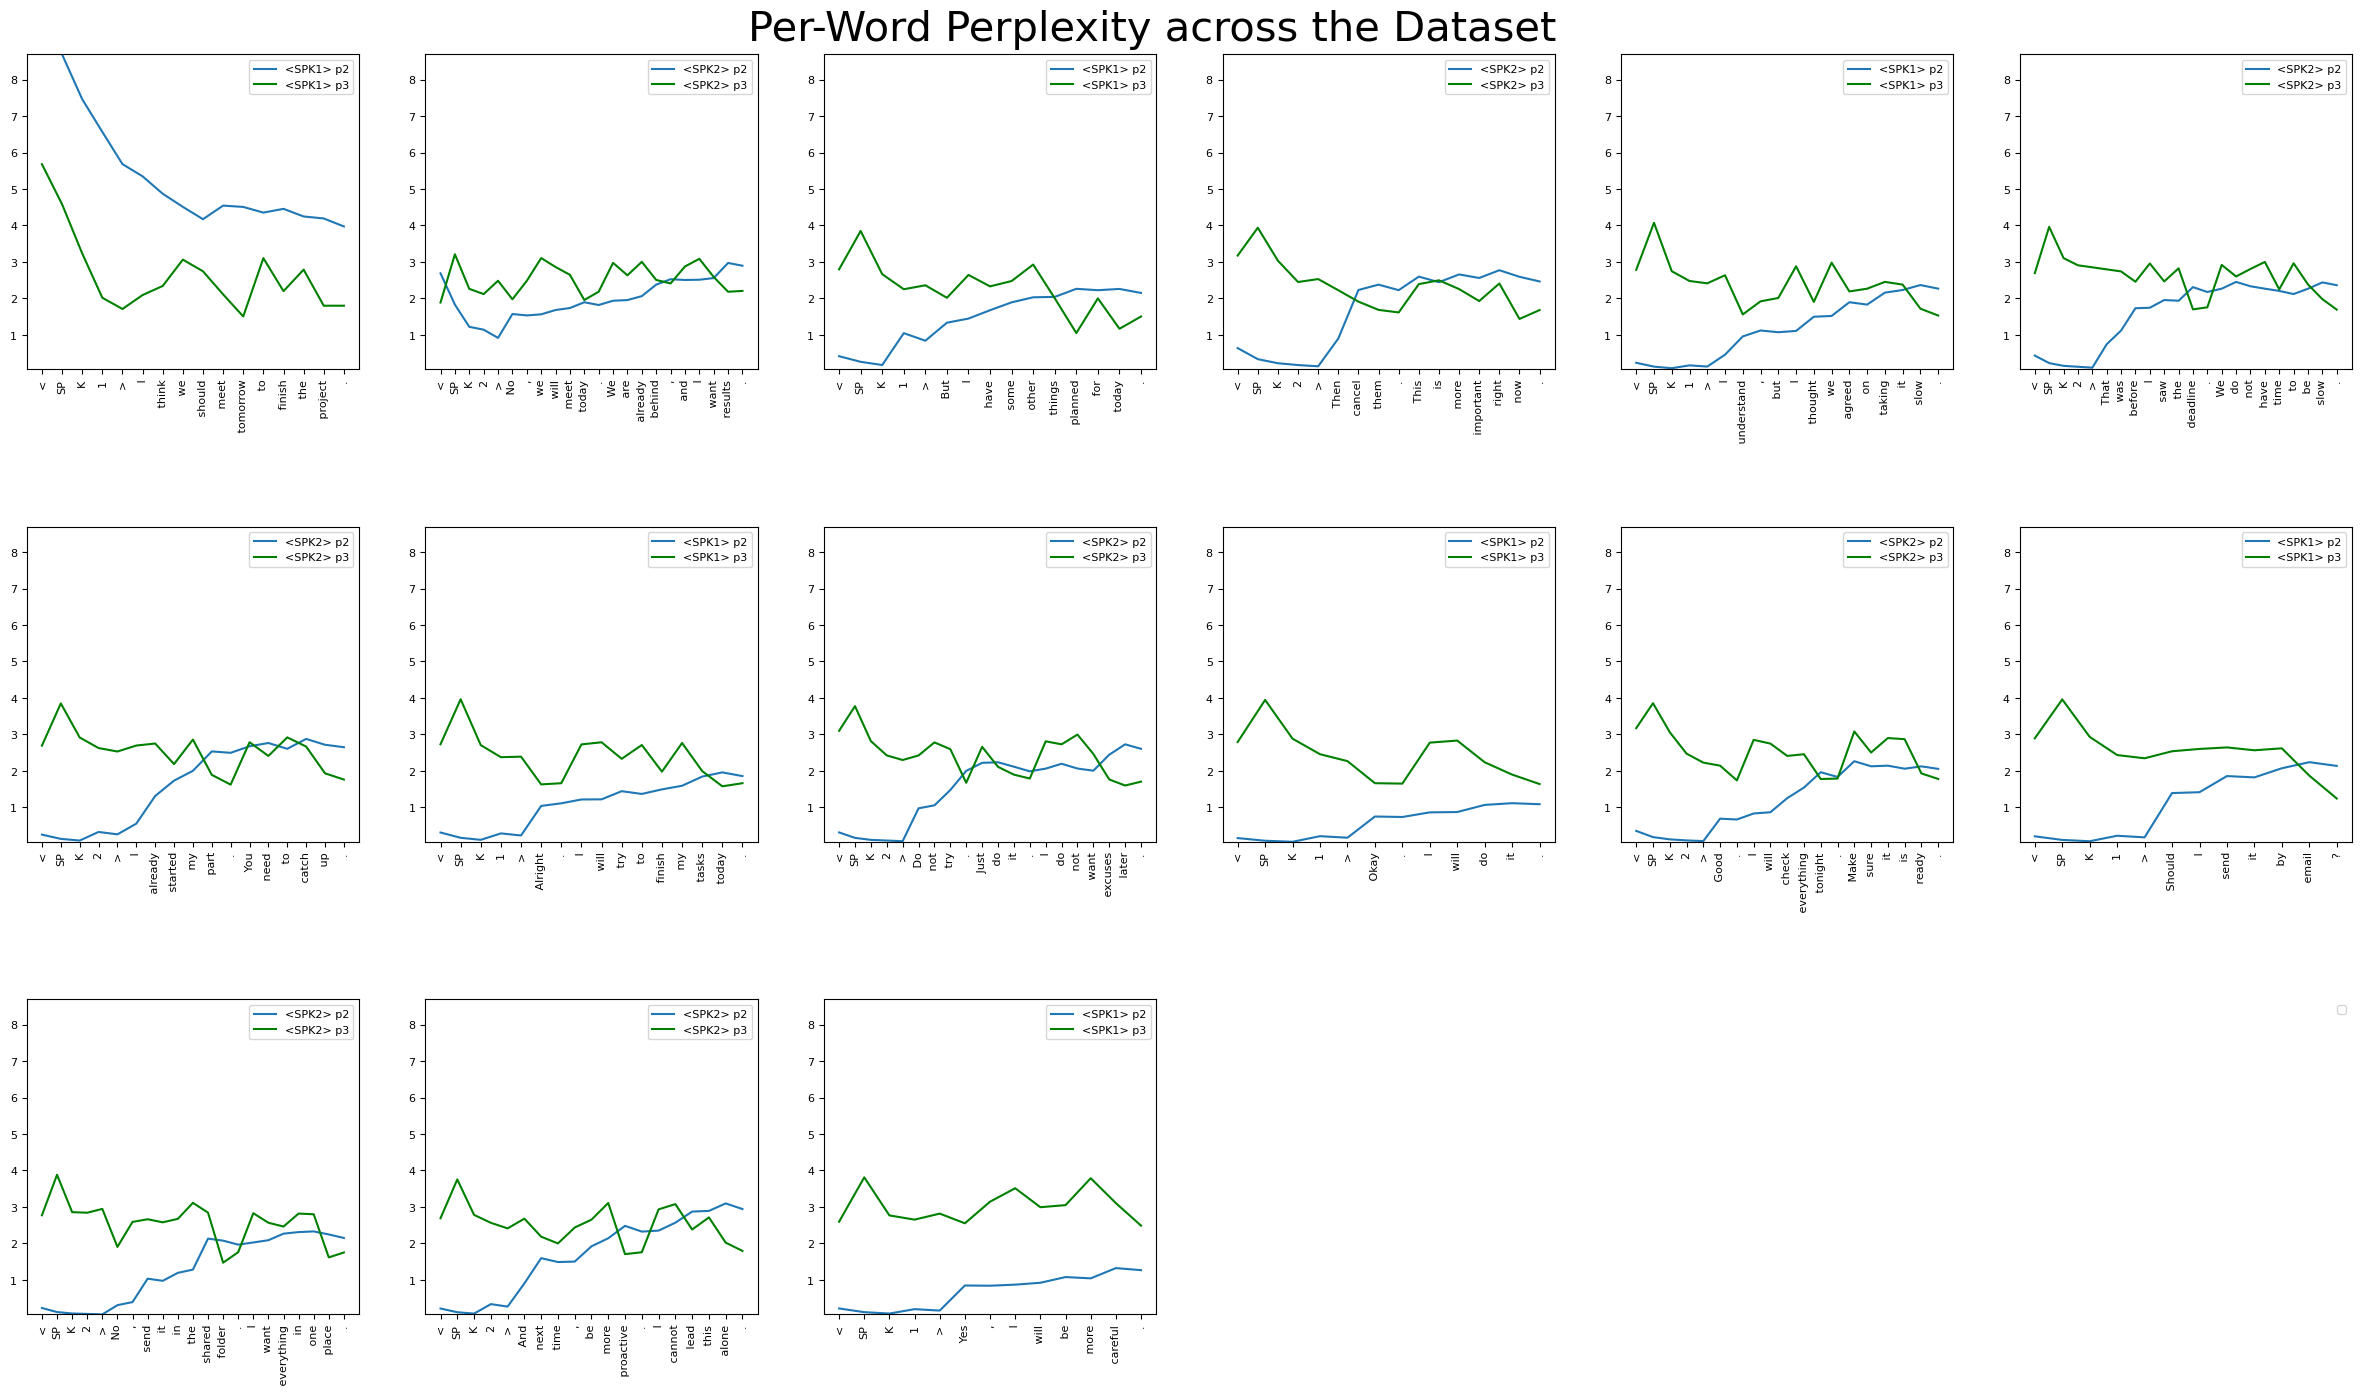

In [22]:
assert len(ppl3_dialog_second_dominant) == len(ppl2_dialog_second_dominant)
compute_graph_perplexity(token_list, ppl2_dialog_second_dominant, ppl3_dialog_second_dominant, matches, names={"p1":"p2", "p2":"p3"})

In [23]:
import os
os.chdir("/u/sebono/conversational_dominance/information_exchange_labelling")
os.getcwd()

'/u/sebono/conversational_dominance/information_exchange_labelling'

In [24]:
from utils import compute_dominance_per_spk, rolling_kde_heatmap_with_turns, remove_match_prefix_ppl, display_colored_sentences

[nltk_data] Downloading package punkt to /u/sebono/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /u/sebono/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [25]:
filtered_tokens_p1, filtered_ppl_p1, filtered_encodings_p1 = remove_match_prefix_ppl(token_list, ppl1_dialog_second_dominant, matches, tokenizer)
assert np.cumsum([len(token) for token in filtered_tokens_p1])[-1], len(filtered_ppl)

In [26]:
filtered_tokens_p2, filtered_ppl_p2, filtered_encodings_p2 = remove_match_prefix_ppl(token_list, ppl2_dialog_second_dominant, matches, tokenizer)
assert np.cumsum([len(token) for token in filtered_tokens_p1])[-1], len(filtered_ppl)

In [27]:
filtered_tokens_p3, filtered_ppl_p3, filtered_encodings_p3 = remove_match_prefix_ppl(token_list, ppl3_dialog_second_dominant, matches, tokenizer)
assert np.cumsum([len(token) for token in filtered_tokens_p1])[-1], len(filtered_ppl)

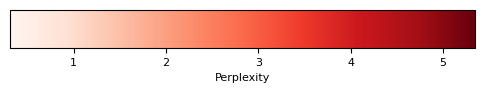

In [30]:
display_colored_sentences(filtered_tokens_p2, filtered_ppl_p2, tokenizer)

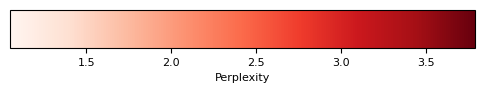

In [31]:
display_colored_sentences(filtered_tokens_p3, filtered_ppl_p3, tokenizer)

## Checks for validity of ps

### Compute Baseline & Normalization
1. Compute the raw P1 scores
2. Compute the baseline P1 scores (e.g., shuffled dialog)
3. Compute the difference: ΔP1 = P1_original - P1_baseline
4. Normalize ΔP1 by length and optionally token rarity

In [ ]:
# Normalize for length and rarity
import torch
import numpy as np
from collections import Counter
from transformers import PreTrainedTokenizer, PreTrainedModel
from typing import List, Dict

def normalize_by_length(p1_scores: List[float], token_list: List[torch.Tensor]) -> List[float]:
    """
    Returns average NLL per utterance (p1 divided by number of tokens per utterance).
    """
    assert len(p1_scores) == sum(len(t) for t in token_list), "Mismatch in token alignment"

    offsets = [0]
    for t in token_list:
        offsets.append(offsets[-1] + len(t))

    p1_by_turn = []
    for i in range(len(token_list)):
        start, end = offsets[i], offsets[i+1]
        turn_nll = p1_scores[start:end]
        avg_nll = np.mean(turn_nll)
        p1_by_turn.append(avg_nll)
    return p1_by_turn


def compute_token_rarity_scores(tokenizer: PreTrainedTokenizer, token_list_flat: List[int]) -> Dict[int, float]:
    """
    Compute token rarity scores as inverse log frequency over the dataset.
    """
    token_counts = Counter(token_list_flat)
    total_tokens = sum(token_counts.values())
    rarity = {
        token: -np.log(count / total_tokens)
        for token, count in token_counts.items()
    }
    return rarity


def normalize_by_rarity(p1_scores: List[float], token_list_flat: List[int], rarity_scores: Dict[int, float]) -> List[float]:
    """
    Adjust NLL values by subtracting expected rarity for each token.
    """
    adjusted = [
        p1 - rarity_scores.get(token, 0.0) for p1, token in zip(p1_scores, token_list_flat)
    ]
    return adjusted

def normalize_p_scores(
    p_scores,
    token_list,
    tokenizer,
    normalize_length=True,
    normalize_rarity=True
):
    """
    General-purpose normalization for token-level perplexity-like scores (e.g., P1, P2, etc.).

    Args:
        p_scores (List[float]): Flattened token-level scores.
        token_list (List[torch.Tensor]): List of token ID tensors per utterance (not flattened).
        tokenizer (PreTrainedTokenizer): HuggingFace tokenizer.
        normalize_length (bool): Whether to normalize by utterance length.
        normalize_rarity (bool): Whether to normalize by token rarity.

    Returns:
        List[float]: Normalized scores (token-level or turn-level depending on flags).
    """
    # Step 1: Normalize by token rarity (keeps token-level granularity)
    if normalize_rarity:
        token_list_flat = [tok.item() for utt in token_list for tok in utt]
        rarity_scores = compute_token_rarity_scores(tokenizer, token_list_flat)
        p_scores = normalize_by_rarity(p_scores, token_list_flat, rarity_scores)

    # Step 2: Normalize by utterance length (reduces to turn-level)
    if normalize_length:
        p_scores = normalize_by_length(p_scores, token_list)

    return p_scores

In [ ]:
from transformers import PreTrainedTokenizer, BatchEncoding
from typing import List, Dict, Union
import numpy as np
import torch

def check_token_mapping(shuffled_dialog):
    orig_enc = shuffled_dialog["original_tokens"]
    shuf_enc = shuffled_dialog["shuffled_tokens"]
    token_map = shuffled_dialog["original_to_shuffled_token_map"]

    orig_ids = orig_enc["input_ids"][0]
    shuf_ids = shuf_enc["input_ids"][0]

    # 1. Lengths must match
    assert orig_ids.size(0) == shuf_ids.size(0), "Token length mismatch"

    # 2. All indices should be mapped exactly once
    assert set(token_map.keys()) == set(range(len(orig_ids))), "Not all original tokens mapped"
    assert set(token_map.values()) == set(range(len(shuf_ids))), "Not all shuffled tokens reached"

    # 3. Check if remapping reproduces the shuffled sequence
    remapped = torch.tensor([shuf_ids[token_map[i]] for i in range(len(orig_ids))])
    assert torch.equal(remapped, orig_ids), "Remapped shuffled tokens do not match original sequence"
    print("✅ Token mapping check passed.")

    
def get_shuffled_dialog_data(
    dialog_lines: List[str],
    tokenizer: PreTrainedTokenizer,
    pattern: str = r"\b[B|E]\b",
    start_of_sentence: str = " ",
    by_turn: bool = True,
    seed: int = 42,
) -> Dict[str, Union[List, Dict, BatchEncoding]]:
    """
    Shuffle a dialog by turn or token while keeping a flat input_ids list aligned with the full encoding.
    Returns both per-turn and flat representations for original and shuffled dialogs, and a mapping from original to shuffled token indices.
    """
    rng = np.random.default_rng(seed)
    pad_token_id = tokenizer.pad_token_id or 0

    # Tokenize each utterance into a list of tensors
    tokenized_turns = [tokenizer(line, return_tensors="pt")["input_ids"][0] for line in dialog_lines]
    turn_lens = [len(t) for t in tokenized_turns]
    total_tokens = sum(turn_lens)

    # Flatten original input_ids
    original_input_ids = torch.cat(tokenized_turns, dim=0)
    original_attention_mask = torch.ones_like(original_input_ids)

    # Full dialog encoding for validation
    full_encoding = tokenizer(start_of_sentence.join(dialog_lines), return_tensors="pt")
    assert full_encoding.input_ids.size(1) == total_tokens, "Mismatch with tokenizer full encoding"

    # Offsets: original turn → token indices
    if by_turn:
        shuffled_indices = rng.permutation(len(dialog_lines))
        shuffled_turns = [tokenized_turns[i] for i in shuffled_indices]
        shuffled_dialog = [dialog_lines[i] for i in shuffled_indices]
        
        original_offsets = [0]
        for t in tokenized_turns:
            original_offsets.append(original_offsets[-1] + len(t))

        # Build token-level mapping
        mapping = {}
        flat_idx = 0
        for shuffled_pos, orig_turn_idx in enumerate(shuffled_indices):
            start = original_offsets[orig_turn_idx]
            end = original_offsets[orig_turn_idx + 1]
            for orig_tok_idx in range(start, end):
                mapping[orig_tok_idx] = flat_idx
                flat_idx += 1
    else:
        # Shuffle tokens globally
        shuffled_indices = rng.permutation(total_tokens)
        shuffled_input_ids = original_input_ids[shuffled_indices]

        # Reconstruct shuffled turns by original lengths
        shuffled_turns = []
        cursor = 0
        for length in turn_lens:
            chunk = shuffled_input_ids[cursor:cursor + length]
            shuffled_turns.append(chunk)
            cursor += length
        shuffled_dialog = [tokenizer.decode(t, skip_special_tokens=True) for t in shuffled_turns]

        # Mapping: original token index → new shuffled index
        mapping = {int(orig): int(new) for new, orig in enumerate(shuffled_indices)}

    # Flatten shuffled turns
    flat_shuffled_input_ids = torch.cat(shuffled_turns, dim=0)
    shuffled_attention_mask = torch.ones_like(flat_shuffled_input_ids)

    # Final consistency checks
    assert flat_shuffled_input_ids.numel() == total_tokens
    assert original_input_ids.numel() == total_tokens

    result = {
        "original_dialog": dialog_lines,
        "shuffled_dialog": shuffled_dialog,
        "original_tokens": BatchEncoding({
            "input_ids": original_input_ids.unsqueeze(0),
            "attention_mask": original_attention_mask.unsqueeze(0),
        }),
        "shuffled_tokens": BatchEncoding({
            "input_ids": flat_shuffled_input_ids.unsqueeze(0),
            "attention_mask": shuffled_attention_mask.unsqueeze(0),
        }),
        "original_per_turn_tokens": tokenized_turns,
        "shuffled_per_turn_tokens": shuffled_turns,
        "original_to_shuffled_token_map": mapping,
    }
    check_token_mapping(result)
    return result

In [ ]:
import matplotlib.pyplot as plt

def plot_comparison(
    p_original,
    p_shuffled,
    tokenizer,
    original_token_list,
    shuffled_token_list,
    original_to_shuffled_token_map: dict,
    title="Impact of Token Shuffling on P1"
):
    """
    Plots token-level comparisons between original and shuffled scores using per-token mapping,
    and returns both the list of figures and reordered shuffled scores.
    
    Args:
        p_original (List[float]): Original token-level scores.
        p_shuffled (List[float]): Shuffled token-level scores.
        tokenizer: HF tokenizer used.
        original_token_list (List[Tensor]): List of token tensors per turn (original).
        shuffled_token_list (List[Tensor]): List of token tensors per turn (shuffled).
        original_to_shuffled_token_map (dict): Maps each original token idx → new shuffled idx.
        title (str): Title prefix.

    Returns:
        figures (List[matplotlib.figure.Figure])
        reordered_shuffled (List[float])
    """

    def compute_token_offsets(token_list):
        offsets = [0]
        for tokens in token_list:
            offsets.append(offsets[-1] + len(tokens))
        return offsets

    original_offsets = compute_token_offsets(original_token_list)
    figures = []
    reordered_shuffled = []

    flat_token_list = [tok for utt in original_token_list for tok in utt]

    for i, turn_tokens in enumerate(original_token_list):
        # Get P1s for the original turn
        start_o, end_o = original_offsets[i], original_offsets[i + 1]
        y_orig = p_original[start_o:end_o]

        # Retrieve shuffled P1s by mapping token indices
        y_shuff = [p_shuffled[original_to_shuffled_token_map[idx]] for idx in range(start_o, end_o)]

        # Decode tokens
        decoded_tokens = tokenizer.convert_ids_to_tokens(turn_tokens.tolist())
        decoded_tokens = [t.replace("Ġ", "").replace("▁", "") for t in decoded_tokens]
        assert len(decoded_tokens) == len(y_orig)
        assert len(y_shuff) == len(y_orig)

        reordered_shuffled.extend(y_shuff)

        # Plot
        x = list(range(len(decoded_tokens)))
        fig, ax = plt.subplots(figsize=(max(8, len(decoded_tokens) * 0.5), 3))
        ax.plot(x, y_orig, label="Original", color="blue", linewidth=2, marker='o')
        ax.plot(x, y_shuff, label="Shuffled", color="orange", linestyle="--", linewidth=2, marker='x')

        ax.set_xticks(x)
        ax.set_xticklabels(decoded_tokens, rotation=45, ha='right')
        ax.set_title(f"{title} — Turn {i}")
        ax.set_xlabel("Tokens")
        ax.set_ylabel("Perplexity")
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.5)
        fig.tight_layout()
        plt.subplots_adjust(bottom=0.3)
        figures.append(fig)
        plt.close

    return figures, reordered_shuffled


In [ ]:
pattern = r'<(?:SPK[0-9]|MOD)>'
dialog_lines = dialog_second_dominant.split("\n")[1:-1]
start_of_sentence=" "
matches = re.findall(pattern, "".join(dialog_lines))
token_list = [tokenizer(token, return_tensors="pt", return_offsets_mapping=True).input_ids[0] for token in dialog]
encodings = tokenizer(f"{start_of_sentence}".join(dialog), return_tensors="pt")

In [ ]:
shuffled_dialog  = get_shuffled_dialog_data(dialog_lines, tokenizer, pattern = pattern, by_turn = False)

In [ ]:
assert encodings.input_ids.size(1) == shuffled_dialog['original_tokens'].input_ids.size(1)
assert shuffled_dialog['shuffled_tokens'].input_ids.size(1) == shuffled_dialog['original_tokens'].input_ids.size(1)

In [ ]:
original_dialog_p1 = compute_p1(shuffled_dialog['original_tokens'], token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)
shuffled_dialog_p1 = compute_p1(shuffled_dialog['shuffled_tokens'], token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)

In [ ]:
original_dialog_p2 = compute_p2(shuffled_dialog['original_tokens'], token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)
shuffled_dialog_p2 = compute_p2(shuffled_dialog['shuffled_tokens'], token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)

In [ ]:
original_dialog_p3 = compute_p3(shuffled_dialog['original_tokens'], token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)
shuffled_dialog_p3 = compute_p3(shuffled_dialog['shuffled_tokens'], token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)

In [ ]:
figures_shuffled_dialog_data_p1, reordered_shuffled_dialog_data_p1 = plot_comparison(original_dialog_p1, shuffled_dialog_p1, tokenizer, shuffled_dialog['original_per_turn_tokens'], shuffled_dialog['original_per_turn_tokens'], shuffled_dialog['original_to_shuffled_token_map'], title="Impact of Floor Structure on P1")

In [ ]:
figures_shuffled_dialog_data_p2, reordered_shuffled_dialog_data_p2 = plot_comparison(original_dialog_p2, shuffled_dialog_p2, tokenizer, shuffled_dialog['original_per_turn_tokens'], shuffled_dialog['shuffled_per_turn_tokens'], shuffled_dialog['original_to_shuffled_token_map'], title="Impact of Floor Structure on P2")

In [ ]:
figures_shuffled_dialog_data_p3, reordered_shuffled_dialog_data_p3 = plot_comparison(original_dialog_p3, shuffled_dialog_p3, tokenizer, shuffled_dialog['original_per_turn_tokens'], shuffled_dialog['shuffled_per_turn_tokens'], shuffled_dialog['original_to_shuffled_token_map'], title="Impact of Floor Structure on P2")

In [ ]:
assert len(original_dialog_p1) == len(reordered_shuffled_dialog_data_p1)
assert len(original_dialog_p2) == len(reordered_shuffled_dialog_data_p2)
assert len(original_dialog_p3) == len(reordered_shuffled_dialog_data_p3)

In [ ]:
original_to_shuffled_token_map = list(range(len(shuffled_dialog['original_tokens'])))
baselined_p1_scores = np.asarray(original_dialog_p1) - np.asarray(reordered_shuffled_dialog_data_p1)
assert len(original_dialog_p1) == len(reordered_shuffled_dialog_data_p1)

baselined_p2_scores = np.asarray(original_dialog_p2) - np.asarray(reordered_shuffled_dialog_data_p2)
assert len(original_dialog_p2) == len(reordered_shuffled_dialog_data_p2)

assert len(original_dialog_p3) == len(reordered_shuffled_dialog_data_p3)
baselined_p3_scores = np.asarray(original_dialog_p3) - np.asarray(reordered_shuffled_dialog_data_p3)


In [ ]:
col_1 = ["p1","p2","p3"]
all_data = pd.DataFrame({"p1":baselined_p1_scores, "p2": baselined_p2_scores, "p3": baselined_p3_scores})
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_1,all_data)

In [ ]:
fig_corr

In [ ]:
import re
import random
from typing import List, Dict, Union
from transformers import PreTrainedTokenizer, BatchEncoding
from torch.nn.utils.rnn import pad_sequence
import torch

def swap_speaker_tokens_with_metadata(
    dialog_lines: List[str],
    tokenizer: PreTrainedTokenizer,
    pattern: str = r"[A-Z]+",
    invert: bool = True,
    swap_percent: float = 0.10
) -> Dict[str, Union[List, BatchEncoding]]:
    """
    Swaps speaker tokens in a dialog and returns both per-turn and flattened tokenizations.
    """

    swapped_dialog = dialog_lines.copy()
    num_lines = len(dialog_lines)

    if invert:
        indices_to_swap = list(range(0, num_lines - 1, 2))
    else:
        max_pairs = (num_lines - 1) // 2
        num_turns_to_swap = max(1, int(num_lines * swap_percent))
        num_pairs_to_swap = min(max_pairs, num_turns_to_swap // 2)

        candidates = list(range(0, num_lines - 1))
        random.shuffle(candidates)

        used = set()
        indices_to_swap = []
        for idx in candidates:
            if idx in used or idx + 1 in used:
                continue
            indices_to_swap.append(idx)
            used.update({idx, idx + 1})
            if len(indices_to_swap) >= num_pairs_to_swap:
                break

    for i in indices_to_swap:
        m1 = re.match(pattern, dialog_lines[i])
        m2 = re.match(pattern, dialog_lines[i + 1])
        if m1 and m2:
            s1, s2 = m1.group(0), m2.group(0)
            b1 = re.sub(pattern, "", dialog_lines[i], count=1)
            b2 = re.sub(pattern, "", dialog_lines[i + 1], count=1)
            swapped_dialog[i] = f"{s2}{b1}"
            swapped_dialog[i + 1] = f"{s1}{b2}"

    # Tokenize each turn and store encoding per-turn (dicts)
    original_tokens_per_turn = [
        tokenizer(line, return_tensors="pt", padding=False, truncation=False)
        for line in dialog_lines
    ]
    swapped_tokens_per_turn = [
        tokenizer(line, return_tensors="pt", padding=False, truncation=False)
        for line in swapped_dialog
    ]

    # Flatten all input_ids and masks
    def flatten(enc_list: List[BatchEncoding]) -> BatchEncoding:
        input_ids = torch.cat([enc["input_ids"][0] for enc in enc_list], dim=0).unsqueeze(0)
        attention_mask = torch.cat([enc["attention_mask"][0] for enc in enc_list], dim=0).unsqueeze(0)
        return BatchEncoding({"input_ids": input_ids, "attention_mask": attention_mask})

    return {
        "original_dialog": dialog_lines,
        "swapped_dialog": swapped_dialog,
        "original_per_turn_tokens": [t.input_ids[0] for t in original_tokens_per_turn],
        "swapped_per_turn_tokens": [t.input_ids[0] for t in swapped_tokens_per_turn],
        "original_tokens": flatten(original_tokens_per_turn),
        "swapped_tokens": flatten(swapped_tokens_per_turn),
    }

In [ ]:
pattern = r'<(?:SPK[0-9]|MOD)>'
dialog_lines = dialog_second_dominant.split("\n")[1:-1]
start_of_sentence=" "
matches = re.findall(pattern, "".join(dialog_lines))
token_list = [tokenizer(token, return_tensors="pt", return_offsets_mapping=True).input_ids[0] for token in dialog]
encodings = tokenizer(f"{start_of_sentence}".join(dialog), return_tensors="pt")

In [ ]:
swapped_dialog = swap_speaker_tokens_with_metadata(dialog_lines, tokenizer, pattern, invert=False)

In [ ]:
original_dialog_p1_swap_speaker_swapped = compute_p1(swapped_dialog['swapped_tokens'], token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)
original_dialog_p1_swap_speaker_original = compute_p1(swapped_dialog['original_tokens'], token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)

In [ ]:
original_dialog_p2_swap_speaker_swapped = compute_p2(swapped_dialog['swapped_tokens'], token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)
original_dialog_p2_swap_speaker_original = compute_p2(swapped_dialog['original_tokens'], token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)

In [ ]:
original_dialog_p3_swap_speaker_swapped = compute_p3(swapped_dialog['swapped_tokens'], token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)
original_dialog_p3_swap_speaker_original = compute_p3(swapped_dialog['original_tokens'], token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)

In [ ]:
original_to_shuffled_token_map = list(range(len(shuffled_dialog['original_tokens'].input_ids[0])))
figures_swap_speaker_tokens_p1, reordered_swap_speaker_tokens_p1 = plot_comparison(original_dialog_p1_swap_speaker_original, original_dialog_p1_swap_speaker_swapped, tokenizer, swapped_dialog['original_per_turn_tokens'], swapped_dialog['original_per_turn_tokens'], original_to_shuffled_token_map, title="Impact of Floor Structure on P1")

In [ ]:
original_to_shuffled_token_map = list(range(len(shuffled_dialog['original_tokens'].input_ids[0])))
figures_swap_speaker_tokens_p2, reordered_swap_speaker_tokens_p2 = plot_comparison(original_dialog_p2_swap_speaker_original, original_dialog_p2_swap_speaker_swapped, tokenizer, swapped_dialog['original_per_turn_tokens'], swapped_dialog['original_per_turn_tokens'], original_to_shuffled_token_map, title="Impact of Floor Structure on P1")

In [ ]:
original_to_shuffled_token_map = list(range(len(shuffled_dialog['original_tokens'].input_ids[0])))
figures_swap_speaker_tokens_p3, reordered_swap_speaker_tokens_p3 = plot_comparison(original_dialog_p3_swap_speaker_original, original_dialog_p3_swap_speaker_swapped, tokenizer, swapped_dialog['original_per_turn_tokens'], swapped_dialog['original_per_turn_tokens'], original_to_shuffled_token_map, title="Impact of Floor Structure on P1")

In [ ]:
original_to_shuffled_token_map = list(range(len(shuffled_dialog['original_tokens'])))
baselined_p1_swap_speaker_token_scores = np.asarray(original_dialog_p1_swap_speaker_original) - np.asarray(original_dialog_p1_swap_speaker_swapped)
assert len(original_dialog_p1_swap_speaker_swapped) == len(original_dialog_p1_swap_speaker_original)

baselined_p2_swap_speaker_token_scores = np.asarray(original_dialog_p2_swap_speaker_original) - np.asarray(original_dialog_p2_swap_speaker_swapped)
assert len(original_dialog_p2_swap_speaker_swapped) == len(original_dialog_p2_swap_speaker_original)

baselined_p3_swap_speaker_token_scores = np.asarray(original_dialog_p3_swap_speaker_original) - np.asarray(original_dialog_p3_swap_speaker_swapped)
assert len(original_dialog_p3_swap_speaker_swapped) == len(original_dialog_p3_swap_speaker_original)

In [ ]:
col_1 = ["p1","p2","p3"]
all_data = pd.DataFrame({"p1":baselined_p1_swap_speaker_token_scores, "p2": baselined_p2_swap_speaker_token_scores, "p3": baselined_p3_swap_speaker_token_scores})
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_1,all_data)

In [ ]:
fig_corr

#### [check!] This should remain the same as changing the names of the speakers shouldn't modify the ppl

In [ ]:
pattern = r'<(?:SPK[0-9]|MOD)>'
dialog = dialog_second_dominant.split("\n")[1:-1]
start_of_sentence=" "
matches = re.findall(pattern, "".join(dialog))
token_list = [tokenizer(token, return_tensors="pt", return_offsets_mapping=True).input_ids[0] for token in dialog]
encodings = tokenizer(f"{start_of_sentence}".join(dialog), return_tensors="pt")

In [ ]:
## Inverting labels!
swapped_dialog = swap_speaker_tokens_with_metadata(dialog_lines, tokenizer, pattern, invert=True)

In [ ]:
original_dialog_p1_swap_speaker_swapped = compute_p1(swapped_dialog['original_tokens'], token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)
original_dialog_p1_swap_speaker_original = compute_p1(swapped_dialog['swapped_tokens'], token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)

In [ ]:
original_dialog_p2_swap_speaker_swapped = compute_p2(swapped_dialog['original_tokens'], token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)
original_dialog_p2_swap_speaker_original = compute_p2(swapped_dialog['swapped_tokens'], token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)

In [ ]:
original_dialog_p3_swap_speaker_swapped = compute_p3(swapped_dialog['original_tokens'], token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)
original_dialog_p3_swap_speaker_original = compute_p3(swapped_dialog['swapped_tokens'], token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)

In [ ]:
original_to_shuffled_token_map = list(range(len(swapped_dialog['original_tokens'].input_ids[0])))
figures_swap_speaker_tokens_p1, reordered_swap_speaker_tokens_p1 = plot_comparison(original_dialog_p1_swap_speaker_original, original_dialog_p1_swap_speaker_swapped, tokenizer, swapped_dialog['original_per_turn_tokens'], swapped_dialog['original_per_turn_tokens'], original_to_shuffled_token_map, title="Impact of Floor Structure on P1")

In [ ]:
original_to_shuffled_token_map = list(range(len(swapped_dialog['original_tokens'].input_ids[0])))
figures_swap_speaker_tokens_p2, reordered_swap_speaker_tokens_p2 = plot_comparison(original_dialog_p2_swap_speaker_original, original_dialog_p2_swap_speaker_swapped, tokenizer, swapped_dialog['original_per_turn_tokens'], swapped_dialog['original_per_turn_tokens'], original_to_shuffled_token_map, title="Impact of Floor Structure on P1")

In [ ]:
original_to_shuffled_token_map = list(range(len(swapped_dialog['original_tokens'].input_ids[0])))
figures_swap_speaker_tokens_p3, reordered_swap_speaker_tokens_p3 = plot_comparison(original_dialog_p3_swap_speaker_original, original_dialog_p3_swap_speaker_swapped, tokenizer, swapped_dialog['original_per_turn_tokens'], swapped_dialog['original_per_turn_tokens'], original_to_shuffled_token_map, title="Impact of Floor Structure on P1")

# Final Test with Baselines

In [ ]:
pattern = r'<(?:SPK[0-9]|MOD)>'
dialog_lines = dialog_second_dominant.split("\n")[1:-1]
start_of_sentence=" "
matches = re.findall(pattern, "".join(dialog_lines))
token_list = [tokenizer(token, return_tensors="pt", return_offsets_mapping=True).input_ids[0] for token in dialog]
encodings = tokenizer(f"{start_of_sentence}".join(dialog), return_tensors="pt")

In [ ]:
shuffled_dialog  = get_shuffled_dialog_data(dialog_lines, tokenizer, pattern = pattern, by_turn = False)

In [ ]:
# P1 - baseline(P1) -- random shuffling of tokens
original_dialog_p1 = compute_p1(shuffled_dialog['original_tokens'], token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)
shuffled_dialog_p1 = compute_p1(shuffled_dialog['shuffled_tokens'], token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)

In [ ]:
figures_shuffled_dialog_data_p1, reordered_shuffled_dialog_data_p1 = plot_comparison(original_dialog_p1, shuffled_dialog_p1, tokenizer, shuffled_dialog['original_per_turn_tokens'], shuffled_dialog['original_per_turn_tokens'], shuffled_dialog['original_to_shuffled_token_map'], title="Impact of Floor Structure on P1")

In [ ]:
original_to_shuffled_token_map = list(range(len(shuffled_dialog['original_tokens'])))
baselined_p1_scores = np.asarray(original_dialog_p1) - np.asarray(reordered_shuffled_dialog_data_p1)
assert len(original_dialog_p1) == len(reordered_shuffled_dialog_data_p1)

In [ ]:
shuffled_dialog  = get_shuffled_dialog_data(dialog_lines, tokenizer, pattern = pattern, by_turn = True)

In [ ]:
# P2 - Baseline(P2) -- random shuffling of turns
original_dialog_p2 = compute_p2(shuffled_dialog['original_tokens'], token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)
shuffled_dialog_p2 = compute_p2(shuffled_dialog['shuffled_tokens'], token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)

In [ ]:
figures_shuffled_dialog_data_p2, reordered_shuffled_dialog_data_p2 = plot_comparison(original_dialog_p2, shuffled_dialog_p2, tokenizer, shuffled_dialog['original_per_turn_tokens'], shuffled_dialog['shuffled_per_turn_tokens'], shuffled_dialog['original_to_shuffled_token_map'], title="Impact of Floor Structure on P2")

In [ ]:
original_to_shuffled_token_map = list(range(len(shuffled_dialog['original_tokens'])))
baselined_p2_scores = np.asarray(original_dialog_p2) - np.asarray(reordered_shuffled_dialog_data_p2)
assert len(original_dialog_p2) == len(reordered_shuffled_dialog_data_p2)

In [ ]:
swapped_dialog = swap_speaker_tokens_with_metadata(dialog_lines, tokenizer, pattern, swap_percent=0.9, invert=False)

In [ ]:
# P3 - baseline(P3) -- random shuffling of tokens
original_dialog_p3 = compute_p3(swapped_dialog['original_tokens'], token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)
swapped_dialog_p3 = compute_p3(swapped_dialog['swapped_tokens'], token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)

In [ ]:
original_to_shuffled_token_map = list(range(len(shuffled_dialog['original_tokens'].input_ids[0])))
figures_swap_speaker_tokens_p3, reordered_swap_speaker_tokens_p3 = plot_comparison(original_dialog_p3, swapped_dialog_p3, tokenizer, swapped_dialog['original_per_turn_tokens'], swapped_dialog['original_per_turn_tokens'], original_to_shuffled_token_map, title="Impact of Floor Structure on P1")

In [ ]:
baselined_p3_scores = np.asarray(original_dialog_p3) - np.asarray(reordered_swap_speaker_tokens_p3)
assert len(original_dialog_p3) == len(reordered_swap_speaker_tokens_p3)

In [ ]:
col_1 = ["p1","p2","p3"]
all_data = pd.DataFrame({"p1":baselined_p1_scores, "p2": baselined_p2_scores, "p3": baselined_p3_scores})
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_1,all_data)

In [ ]:
fig_corr

## Sanity check using Candor

In [ ]:
def reorder_tokens(
    p_original,
    p_shuffled,
    tokenizer,
    original_token_list,
    shuffled_token_list,
    original_to_shuffled_token_map: dict,
    title="Impact of Token Shuffling on P1"
):
    """
    Plots token-level comparisons between original and shuffled scores using per-token mapping,
    and returns both the list of figures and reordered shuffled scores.
    
    Args:
        p_original (List[float]): Original token-level scores.
        p_shuffled (List[float]): Shuffled token-level scores.
        tokenizer: HF tokenizer used.
        original_token_list (List[Tensor]): List of token tensors per turn (original).
        shuffled_token_list (List[Tensor]): List of token tensors per turn (shuffled).
        original_to_shuffled_token_map (dict): Maps each original token idx → new shuffled idx.
        title (str): Title prefix.

    Returns:
        figures (List[matplotlib.figure.Figure])
        reordered_shuffled (List[float])
    """

    def compute_token_offsets(token_list):
        offsets = [0]
        for tokens in token_list:
            offsets.append(offsets[-1] + len(tokens))
        return offsets

    original_offsets = compute_token_offsets(original_token_list)
    figures = []
    reordered_shuffled = []

    flat_token_list = [tok for utt in original_token_list for tok in utt]

    for i, turn_tokens in enumerate(original_token_list):
        # Get P1s for the original turn
        start_o, end_o = original_offsets[i], original_offsets[i + 1]
        y_orig = p_original[start_o:end_o]

        # Retrieve shuffled P1s by mapping token indices
        y_shuff = [p_shuffled[original_to_shuffled_token_map[idx]] for idx in range(start_o, end_o)]

        # Decode tokens
        decoded_tokens = tokenizer.convert_ids_to_tokens(turn_tokens.tolist())
        decoded_tokens = [t.replace("Ġ", "").replace("▁", "") for t in decoded_tokens]
        assert len(decoded_tokens) == len(y_orig)
        assert len(y_shuff) == len(y_orig)

        reordered_shuffled.extend(y_shuff)

    return reordered_shuffled

In [ ]:
import pandas as pd
candor_df = pd.read_csv("/u/sebono/conversational_dominance/data/processed/CANDOR_gpt2-large/conversations.csv")
candor_df.head()

In [ ]:
name_file = candor_df.iloc[0]["file_name"]
conversation = candor_df.iloc[0]["file_content"]

In [ ]:
import re 
pattern = r'<(?:SPK[0-9]|MOD)>'
dialog_lines = conversation.replace(" <", "\n<").split("\n")[1:]
start_of_sentence=" "
matches = re.findall(pattern, "".join(dialog_lines))
token_list = [tokenizer(token, return_tensors="pt").input_ids[0] for token in dialog_lines]
encodings = tokenizer(f"{start_of_sentence}".join(dialog_lines), return_tensors="pt")

In [ ]:
shuffled_dialog  = get_shuffled_dialog_data(dialog_lines, tokenizer, pattern = pattern, by_turn = False)

In [ ]:
# P1 - baseline(P1) -- random shuffling of tokens
original_dialog_p1 = compute_p1(shuffled_dialog['original_tokens'], token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)
shuffled_dialog_p1 = compute_p1(shuffled_dialog['shuffled_tokens'], token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)

In [ ]:
reordered_shuffled_dialog_data_p1 = reorder_tokens(original_dialog_p1, shuffled_dialog_p1, tokenizer, shuffled_dialog['original_per_turn_tokens'], shuffled_dialog['original_per_turn_tokens'], shuffled_dialog['original_to_shuffled_token_map'], title="Impact of Floor Structure on P1")

In [ ]:
original_to_shuffled_token_map = list(range(len(shuffled_dialog['original_tokens'])))
baselined_p1_scores = np.asarray(original_dialog_p1) - np.asarray(reordered_shuffled_dialog_data_p1)
assert len(original_dialog_p1) == len(reordered_shuffled_dialog_data_p1)

In [ ]:
shuffled_dialog  = get_shuffled_dialog_data(dialog_lines, tokenizer, pattern = pattern, by_turn = True)

In [ ]:
# P2 - Baseline(P2) -- random shuffling of turns
original_dialog_p2 = compute_p2(shuffled_dialog['original_tokens'], token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)
shuffled_dialog_p2 = compute_p2(shuffled_dialog['shuffled_tokens'], token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)

In [ ]:
reordered_shuffled_dialog_data_p2 = reorder_tokens(original_dialog_p2, shuffled_dialog_p2, tokenizer, shuffled_dialog['original_per_turn_tokens'], shuffled_dialog['shuffled_per_turn_tokens'], shuffled_dialog['original_to_shuffled_token_map'], title="Impact of Floor Structure on P2")

In [ ]:
original_to_shuffled_token_map = list(range(len(shuffled_dialog['original_tokens'])))
baselined_p2_scores = np.asarray(original_dialog_p2) - np.asarray(reordered_shuffled_dialog_data_p2)
assert len(original_dialog_p2) == len(reordered_shuffled_dialog_data_p2)

In [ ]:
swapped_dialog = swap_speaker_tokens_with_metadata(dialog_lines, tokenizer, pattern, swap_percent=0.9, invert=False)

In [ ]:
# P3 - baseline(P3) -- random shuffling of tokens
original_dialog_p3 = compute_p3(swapped_dialog['original_tokens'], token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)
swapped_dialog_p3 = compute_p3(swapped_dialog['swapped_tokens'], token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)

In [ ]:
original_to_shuffled_token_map = list(range(len(shuffled_dialog['original_tokens'].input_ids[0])))
reordered_swap_speaker_tokens_p3 = reorder_tokens(original_dialog_p3, swapped_dialog_p3, tokenizer, swapped_dialog['original_per_turn_tokens'], swapped_dialog['original_per_turn_tokens'], original_to_shuffled_token_map, title="Impact of Floor Structure on P1")

In [ ]:
baselined_p3_scores = np.asarray(original_dialog_p3) - np.asarray(reordered_swap_speaker_tokens_p3)
assert len(original_dialog_p3) == len(reordered_swap_speaker_tokens_p3)

In [ ]:
file_name = f"../information_exchange_labelling/{candor_df.iloc[0]['file_name']}_candor_ppl.csv"
all_data = pd.DataFrame({'baselined_p1_scores':baselined_p1_scores, 'baselined_p2_scores':baselined_p2_scores, 'baselined_p3_scores':baselined_p3_scores,
       'original_dialog_p1':original_dialog_p1, 'original_dialog_p2':original_dialog_p2, 'original_dialog_p3':original_dialog_p3})
all_data.to_csv(file_name, index=False)

In [ ]:
col_1 = ["p1","p2","p3"]
all_data = pd.DataFrame({"p1":baselined_p1_scores, "p2": baselined_p2_scores, "p3": baselined_p3_scores})
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_1,all_data)

### After Baselining

In [ ]:
fig_corr

### Before Baselining

In [ ]:
col_1 = ["p1","p2","p3"]
all_data = pd.DataFrame({"p1":original_dialog_p1, "p2": original_dialog_p2, "p3": original_dialog_p3})
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_1,all_data)

In [ ]:
fig_corr

### Self Correlation

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
import plotly
import plotly.io as pio
pio.renderers.default = 'iframe'
import plotly.express as px
plotly.offline.init_notebook_mode(connected=True)
import seaborn as sns

cmp = 'algae'
def correlation_heatmap(y_cols, x_cols, full_data):
    '''
    Uses scipy.stats.spearmanr function
    Params:
    y_cols, x_cols: sets of column titles (strings)
    full_data: pandas dataframe that includes all columns listed in y_cols, x_cols
    Returns:
    corr: Spearman correlation coefficient matrix (y_cols = rows, x_cols = cols of matrix)
    fig_corr: annotated plotly heatmap of coefficients
    p: Spearman p-value matrix
    fig_p: annotated plotly heatmap of p-values
    '''
    cols = y_cols+x_cols
    all_correlations = scipy.stats.spearmanr(full_data[cols], nan_policy='omit')
    corr = all_correlations.statistic[:len(y_cols), -len(x_cols):]
    corr = pd.DataFrame(corr)
    corr.columns = x_cols
    corr.index = y_cols

    p = all_correlations.pvalue[:len(y_cols), -len(x_cols):]
    p = pd.DataFrame(p)
    p.columns = x_cols
    p.index = y_cols
    
    fig_corr = px.imshow(corr, text_auto=True, aspect='auto', color_continuous_scale='agsunset')
    fig_r2 = px.imshow(corr**2, text_auto=True, aspect='auto', color_continuous_scale='agsunset')
    fig_p = px.imshow(p, text_auto=True, aspect='auto', color_continuous_scale='gray_r')

    return corr, fig_corr, p, fig_p, fig_r2

In [ ]:
num_turns = 50
upper_limit = np.cumsum([len(token) for token in token_list])[num_turns]

In [ ]:
compute_graph_perplexity(token_list[:num_turns + 1], original_dialog_p2[:upper_limit], original_dialog_p3[:upper_limit], matches[:num_turns + 1], names={"p1":"p2", "p2":"p3"})